
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Dimensiones de la placa
a = 20.0   # mm
b = 10.0   # mm

# Difusividad térmica del aluminio
D = 84.0   # mm^2/s

dx = 0.2
dy = 0.2

nx = int(a/dx) + 1
ny = int(b/dy) + 1

#coordenadas
x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)

X, Y = np.meshgrid(x, y, indexing='ij') #malla

T = np.zeros((nx, ny))

T[:, 0] = 0.0
T[0, :] = 0.0
T[-1, :] = 0.0
T[:, -1] = 100*np.sin(3*np.pi*x/a)

In [3]:
def Laplace2D(T_ini, tol=1e-6, max_iter=20000):

    T = T_ini.copy()

    for it in range(max_iter):

        T_prev = T.copy()

        T[1:-1, 1:-1] = 0.25 * (
            T_prev[2:, 1:-1] +
            T_prev[:-2, 1:-1] +
            T_prev[1:-1, 2:] +
            T_prev[1:-1, :-2]
        )

        err = np.max(np.abs(T - T_prev))

        if err < tol:
            break

    return T, it, err

In [4]:
T_fdm, iteraciones, error = Laplace2D(
    T,
    tol=1e-6,
    max_iter=20000
)

print("Iteraciones:", iteraciones)
print("Error final:", error)

Iteraciones: 3441
Error final: 9.99187967920534e-07


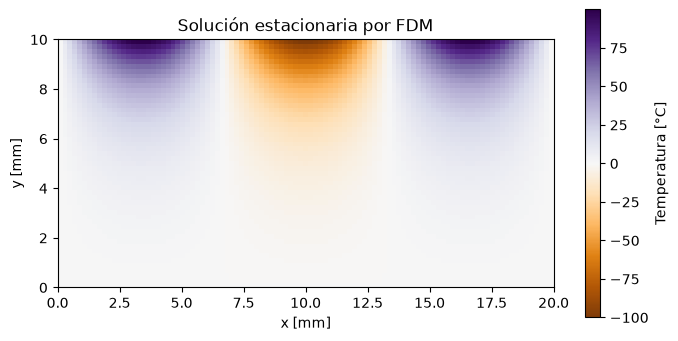

In [28]:
plt.figure(figsize=(8,4))

plt.imshow(
    T_fdm.T,
    origin='lower',
    extent=[0, a, 0, b],
    aspect='equal',
    cmap = 'PuOr'
)

plt.colorbar(label='Temperatura [°C]')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.title('Solución estacionaria por FDM')

plt.show()

### Solución analítica

Para comparar la solución obtenida mediante FDM, se utiliza la solución analítica de la ecuación de Laplace,

$$
\nabla^2 T =
\frac{\partial^2T}{\partial x^2}
+
\frac{\partial^2T}{\partial y^2}=0.
$$

Aplicando separación de variables y teniendo en cuenta las condiciones de frontera
$T(0,y)=T(a,y)=T(x,0)=0$ y

$$
T(x,b)=100\sin\left(\frac{3\pi x}{a}\right),
$$

se obtiene:

$$
\boxed{
T(x,y)=
100\sin\left(\frac{3\pi x}{a}\right)
\frac{\sinh\left(\frac{3\pi y}{a}\right)}
{\sinh\left(\frac{3\pi b}{a}\right)}
}
$$

Esta expresión se evalúa en los mismos puntos de la malla utilizados para la solución FDM y posteriormente se compara con ella mediante el cálculo del error máximo.

In [10]:
T_analitica = (
    100
    * np.sin(3 * np.pi * X / a)
    * np.sinh(3 * np.pi * Y / a)
    / np.sinh(3 * np.pi * b / a)
)

error = T_fdm - T_analitica
error_abs = np.abs(error)
error_max = np.max(error_abs)

print(f"Error máximo = {error_max:.6f} °C")

Error máximo = 0.026876 °C


### Solución temporal mediante FDM

Para estudiar la evolución de la temperatura se utiliza la ecuación de difusión

$$
\frac{\partial T}{\partial t}
=
D\left(
\frac{\partial^2T}{\partial x^2}
+
\frac{\partial^2T}{\partial y^2}
\right).
$$

Usando diferencias finitas hacia adelante en el tiempo y centradas en el espacio, se obtiene

$$
T_{i,j}^{n+1}
=
T_{i,j}^{n}
+
\frac{D\Delta t}{\Delta^2}
\left[
T_{i+1,j}^{n}
+T_{i-1,j}^{n}
+T_{i,j+1}^{n}
+T_{i,j-1}^{n}
-4T_{i,j}^{n}
\right].
$$

Para garantizar la estabilidad del método explícito se requiere

$$
\Delta t \leq \frac{\Delta^2}{4D}.
$$

La placa se considera inicialmente a $0^\circ\mathrm{C}$, mientras que el borde superior se mantiene fijo según
$T(x,b)=100\sin(3\pi x/a)$.

In [11]:
#paso temporal
dt_max = dx**2 / (4*D)

dt = 0.9 * dt_max

print(f"dt máximo = {dt_max:.6e} s")
print(f"dt utilizado = {dt:.6e} s")

dt máximo = 1.190476e-04 s
dt utilizado = 1.071429e-04 s


In [12]:
T0 = np.zeros((nx, ny))

 #condiciones de frontera 
T0[:, -1] = 100*np.sin(3*np.pi*x/a)
T0[0, :] = 0
T0[-1, :] = 0
T0[:, 0] = 0

In [ ]:
def do_timestep(T):
    
    T_new = T.copy()

    T_new[1:-1, 1:-1] = (
        T[1:-1, 1:-1]
        + D*dt/dx**2 * (
            T[2:, 1:-1]
            + T[:-2, 1:-1]
            + T[1:-1, 2:]
            + T[1:-1, :-2]
            - 4*T[1:-1, 1:-1]
        )
    )

    return T_new

times = [0.0, 0.01, 0.5]
T = T0.copy()

snapshots = {}

for t_objetivo in times:

    T = T0.copy()

    nsteps = int(round(t_objetivo / dt))

    for _ in range(nsteps):
        T = do_timestep(T)

    snapshots[t_objetivo] = T.copy()


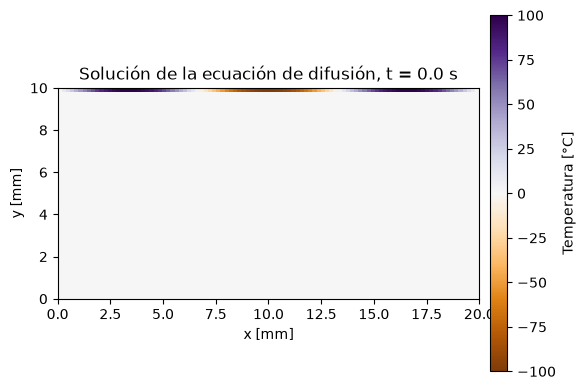

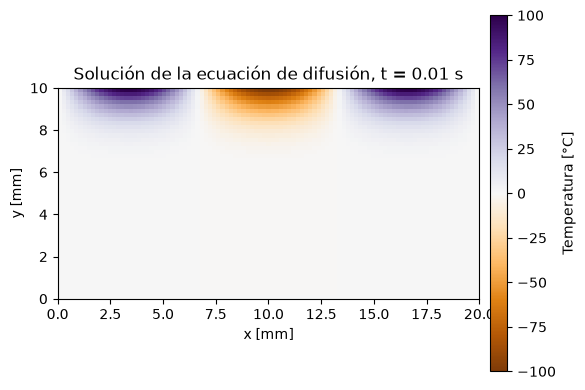

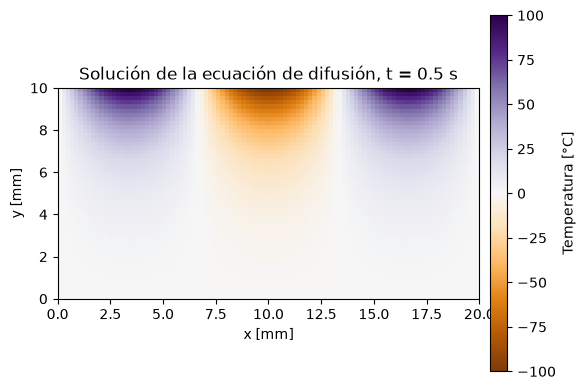

In [38]:
for t in times:

    plt.figure(figsize=(6, 4))

    im = plt.imshow(
        snapshots[t].T,
        origin='lower',
        extent=[0, a, 0, b],
        aspect='equal',
        cmap='PuOr',
        vmin=-100,
        vmax=100
    )

    plt.colorbar(im, label='Temperatura [°C]', pad=0.02)

    plt.xlabel('x [mm]')
    plt.ylabel('y [mm]')
    plt.title(f'Solución de la ecuación de difusión, t = {t} s')

    plt.tight_layout()
    plt.show()